In [ ]:
# The Bandit Exercise

In [ ]:
import numpy as np

# Class for a single slot machine. Rewards are Gaussian.
class GaussianBandit(object):
    def __init__(self, mean=0, stdev=1):
        self.mean = mean
        self.stdev = stdev

    def pull_lever(self):
        reward = np.random.normal(self.mean, self.stdev)
        return np.round(reward, 1)

In [ ]:
g1 = GaussianBandit(5, 2)
g2 = GaussianBandit(6, 2)
g3 = GaussianBandit(1, 5)

In [ ]:
g1.pull_lever()

np.float64(7.7)

In [ ]:
class GaussianBanditGame(object):
    def __init__(self, bandits):
        self.bandits = bandits
        np.random.shuffle(self.bandits)
        self.reset_game()

    def play(self, choice):
        reward = self.bandits[choice - 1].pull_lever()
        self.rewards.append(reward)
        self.total_reward += reward
        self.n_played += 1
        return reward

    def user_play(self):
        self.reset_game()
        print("Game started. " +
              "Enter 0 as input to end the game.")
        while True:
            print(f"\n -- Round {self.n_played}")
            choice = int(input(f"Choose a machine " +
                     f"from 1 to {len(self.bandits)}: "))
            if choice in range(1, len(self.bandits) + 1):
                reward = self.play(choice)
                print(f"Machine {choice} gave " +
                      f"a reward of {reward}.")
                avg_rew = self.total_reward/self.n_played
                print(f"Your average reward " +
                      f"so far is {avg_rew}.")
            else:
                break
        print("Game has ended.")
        if self.n_played > 0:
            print(f"Total reward is {self.total_reward}" +
                  f" after {self.n_played} round(s).")
            avg_rew = self.total_reward/self.n_played
            print(f"Average reward is {avg_rew}.")

    def reset_game(self):
        self.rewards = []
        self.total_reward = 0
        self.n_played = 0

In [ ]:
slotA = GaussianBandit(5, 3)
slotB = GaussianBandit(6, 2)
slotC = GaussianBandit(1, 5)
game = GaussianBanditGame([slotA, slotB, slotC])

In [ ]:
game.user_play()

Game started. Enter 0 as input to end the game.

 -- Round 0
Choose a machine from 1 to 3: 1
Machine 1 gave a reward of 5.4.
Your average reward so far is 5.4.

 -- Round 1
Choose a machine from 1 to 3: 1
Machine 1 gave a reward of -2.4.
Your average reward so far is 1.5000000000000002.

 -- Round 2
Choose a machine from 1 to 3: 1
Machine 1 gave a reward of 3.5.
Your average reward so far is 2.1666666666666665.

 -- Round 3
Choose a machine from 1 to 3: 0
Game has ended.
Total reward is 6.5 after 3 round(s).
Average reward is 2.1666666666666665.


In [ ]:
print(game.bandits[0].mean)
print(game.bandits[1].mean)
print(game.bandits[2].mean)

1
5
6


In [ ]:
# Case study – online advertising

In [ ]:
class BernoulliBandit(object):
    def __init__(self, p):
        self.p = p

    def display_ad(self):
        reward = np.random.binomial(n=1, p=self.p)
        return reward

In [ ]:
adA = BernoulliBandit(0.004)
adB = BernoulliBandit(0.016)
adC = BernoulliBandit(0.02)
adD = BernoulliBandit(0.028)
adE = BernoulliBandit(0.031)

In [ ]:
ads = [adA, adB, adC, adD, adE]

In [ ]:
np.random.binomial(n=1000000, p=0.5)

500067

In [ ]:
# A/B/n Testing

In [ ]:
n_test = 10000
n_prod = 90000
n_ads = len(ads)
Q = np.zeros(n_ads)  # Q, action values
N = np.zeros(n_ads)  # N, total impressions
total_reward = 0
avg_rewards = []  # Save average rewards over time

In [ ]:
# A/B/n test
for i in range(n_test):
    ad_chosen = np.random.randint(n_ads)
    R = ads[ad_chosen].display_ad()  # Observe reward
    N[ad_chosen] += 1
    Q[ad_chosen] += (1 / N[ad_chosen]) * (R - Q[ad_chosen])
    total_reward += R
    avg_reward_so_far = total_reward / (i + 1)
    avg_rewards.append(avg_reward_so_far)

In [ ]:
best_ad_index = np.argmax(Q)  # Find the best action
print("The best performing ad is {}".format(chr(ord('A') + best_ad_index)))

The best performing ad is D


In [ ]:
ad_chosen = best_ad_index
for i in range(n_prod):
    R = ads[ad_chosen].display_ad()
    total_reward += R
    avg_reward_so_far = total_reward / (n_test + i + 1)
    avg_rewards.append(avg_reward_so_far)

In [ ]:
import pandas as pd
df_reward_comparison = pd.DataFrame(avg_rewards, columns=['A/B/n'])

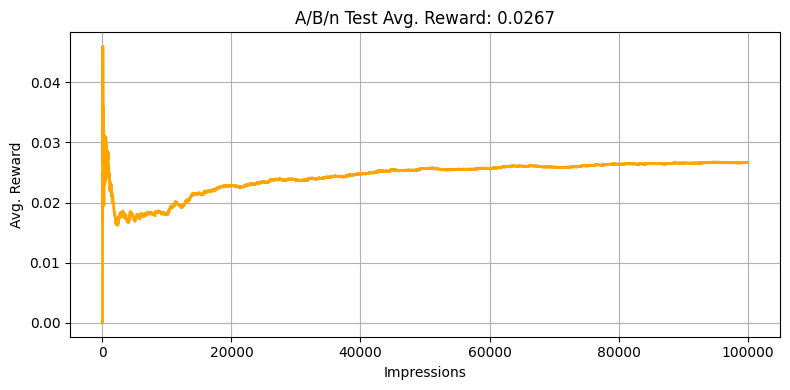

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(df_reward_comparison['A/B/n'], color='orange', linewidth=2)
plt.title(f"A/B/n Test Avg. Reward: {avg_reward_so_far:.4f}")
plt.xlabel('Impressions')
plt.ylabel('Avg. Reward')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# epsilon greedy

In [ ]:
eps = 0.1
n_prod = 100000
n_ads = len(ads)
Q = np.zeros(n_ads)
N = np.zeros(n_ads)
total_reward = 0
avg_rewards = []

In [ ]:
ad_chosen = np.random.randint(n_ads)
for i in range(n_prod):
    R = ads[ad_chosen].display_ad()
    N[ad_chosen] += 1
    Q[ad_chosen] += (1 / N[ad_chosen]) * (R - Q[ad_chosen])
    total_reward += R
    avg_reward_so_far = total_reward / (i + 1)
    avg_rewards.append(avg_reward_so_far)

    # Select the next ad to display
    if np.random.uniform() <= eps:
        ad_chosen = np.random.randint(n_ads)
    else:
        ad_chosen = np.argmax(Q)

df_reward_comparison['e-greedy: {}'.format(eps)] = avg_rewards

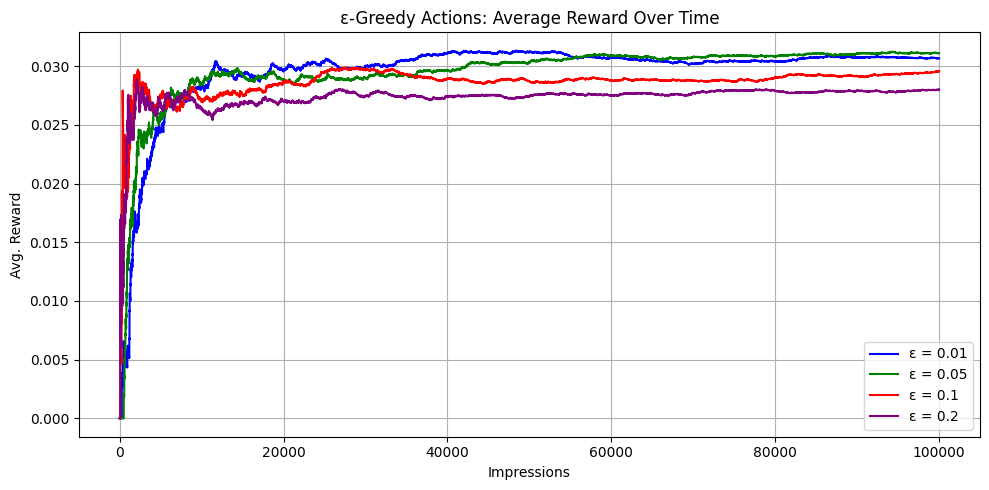

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Epsilon values to test
eps_values = [0.01, 0.05, 0.1, 0.2]
colors = ['blue', 'green', 'red', 'purple']  # One color per epsilon

plt.figure(figsize=(10, 5))

for eps, color in zip(eps_values, colors):
    # Initialize variables for each epsilon
    n_prod = 100000
    n_ads = len(ads)
    Q = np.zeros(n_ads)
    N = np.zeros(n_ads)
    total_reward = 0
    avg_rewards = []

    ad_chosen = np.random.randint(n_ads)
    for i in range(n_prod):
        R = ads[ad_chosen].display_ad()
        N[ad_chosen] += 1
        Q[ad_chosen] += (1 / N[ad_chosen]) * (R - Q[ad_chosen])
        total_reward += R
        avg_reward_so_far = total_reward / (i + 1)
        avg_rewards.append(avg_reward_so_far)

        # Epsilon-greedy selection
        if np.random.uniform() <= eps:
            ad_chosen = np.random.randint(n_ads)
        else:
            ad_chosen = np.argmax(Q)

    # Save results in DataFrame
    df_reward_comparison[f'e-greedy: {eps}'] = avg_rewards

    # Plot the curve
    plt.plot(avg_rewards, color=color, linestyle='solid', label=f'ε = {eps}')

plt.title("ε-Greedy Actions: Average Reward Over Time")
plt.xlabel("Impressions")
plt.ylabel("Avg. Reward")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# UCB

In [ ]:
c = 0.1
n_prod = 100000
n_ads = len(ads)
ad_indices = np.array(range(n_ads))
Q = np.zeros(n_ads)
N = np.zeros(n_ads)
total_reward = 0
avg_rewards = []

In [ ]:
for t in range(1, n_prod + 1):
    if any(N==0):
        ad_chosen = np.random.choice(ad_indices[N==0])
    else:
        uncertainty = np.sqrt(np.log(t) / N)
        ad_chosen = np.argmax(Q +  c * uncertainty)

    R = ads[ad_chosen].display_ad()
    N[ad_chosen] += 1
    Q[ad_chosen] += (1 / N[ad_chosen]) * (R - Q[ad_chosen])
    total_reward += R
    avg_reward_so_far = total_reward / t
    avg_rewards.append(avg_reward_so_far)

df_reward_comparison['UCB, c={}'.format(c)] = avg_rewards

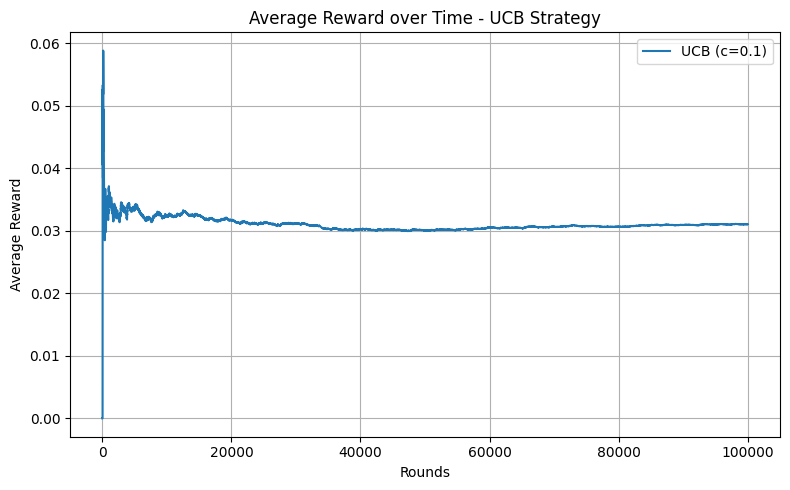

In [ ]:
# Plot average reward over time
plt.figure(figsize=(8, 5))
plt.plot(avg_rewards, label=f'UCB (c={c})')

# Optional: compare with other strategies
# plt.plot(df_reward_comparison['Epsilon-Greedy'], label='ε-Greedy (ε=0.1)')

plt.title('Average Reward over Time - UCB Strategy')
plt.xlabel('Rounds')
plt.ylabel('Average Reward')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

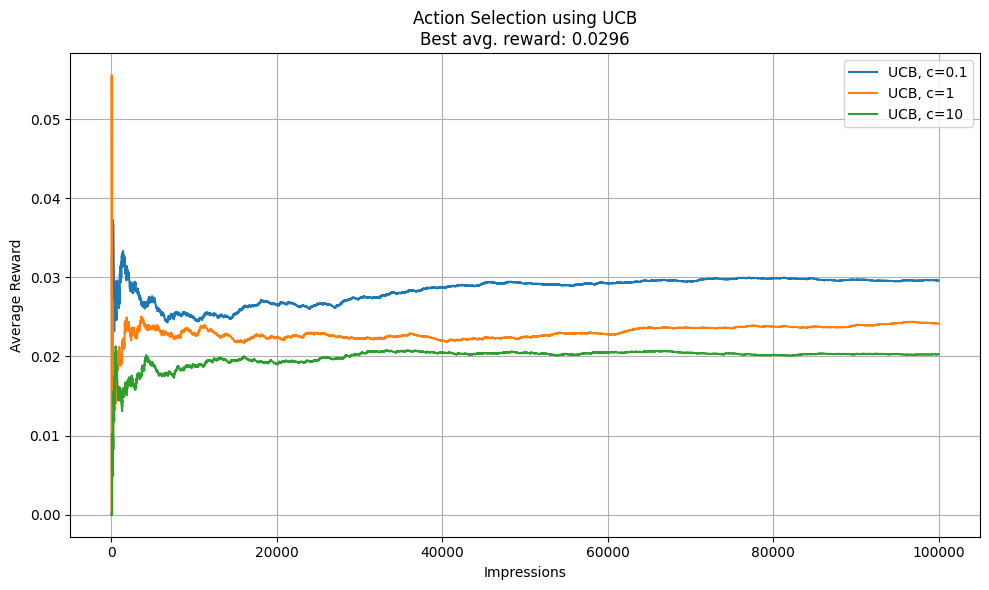

In [ ]:
# UCB experiment with different c values

# UCB hyperparameters to test
ucb_list = ['UCB, c=0.1', 'UCB, c=1', 'UCB, c=10']
c_values = [0.1, 1, 10]
n_prod = 100000
n_ads = len(ads)
ad_indices = np.arange(n_ads)

# Run UCB for each c
for c in c_values:
    Q = np.zeros(n_ads)
    N = np.zeros(n_ads)
    total_reward = 0
    avg_rewards = []

    for t in range(1, n_prod + 1):
        if np.any(N == 0):
            ad_chosen = np.random.choice(ad_indices[N == 0])
        else:
            uncertainty = np.sqrt(np.log(t) / N)
            ad_chosen = np.argmax(Q + c * uncertainty)

        R = ads[ad_chosen].display_ad()
        N[ad_chosen] += 1
        Q[ad_chosen] += (1 / N[ad_chosen]) * (R - Q[ad_chosen])
        total_reward += R
        avg_rewards.append(total_reward / t)

    df_reward_comparison[f'UCB, c={c}'] = avg_rewards

# Get best final average reward across all UCB variants
best_reward = df_reward_comparison.iloc[-1][ucb_list].max()

# Plot using matplotlib
plt.figure(figsize=(10, 6))
for col in ucb_list:
    plt.plot(df_reward_comparison[col], label=col)

plt.title(f'Action Selection using UCB\nBest avg. reward: {best_reward:.4f}')
plt.xlabel('Impressions')
plt.ylabel('Average Reward')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Print final average reward for each UCB c
for c in c_values:
    col_name = f'UCB, c={c}'
    final_avg = df_reward_comparison[col_name].iloc[-1]  # last value
    print(f'{col_name}: Final average reward = {final_avg:.4f}')


UCB, c=0.1: Final average reward = 0.0296
UCB, c=1: Final average reward = 0.0242
UCB, c=10: Final average reward = 0.0203


In [ ]:
# Thompson Sampling

In [ ]:
n_prod = 100000
n_ads = len(ads)
alphas = np.ones(n_ads)
betas = np.ones(n_ads)
total_reward = 0
avg_rewards = []

In [ ]:
for i in range(n_prod):
    theta_samples = [np.random.beta(alphas[k], betas[k]) for k in range(n_ads)]
    ad_chosen = np.argmax(theta_samples)
    R = ads[ad_chosen].display_ad()
    alphas[ad_chosen] += R
    betas[ad_chosen] += 1 - R
    total_reward += R
    avg_reward_so_far = total_reward / (i + 1)
    avg_rewards.append(avg_reward_so_far)
df_reward_comparison['Thompson Sampling'] = avg_rewards

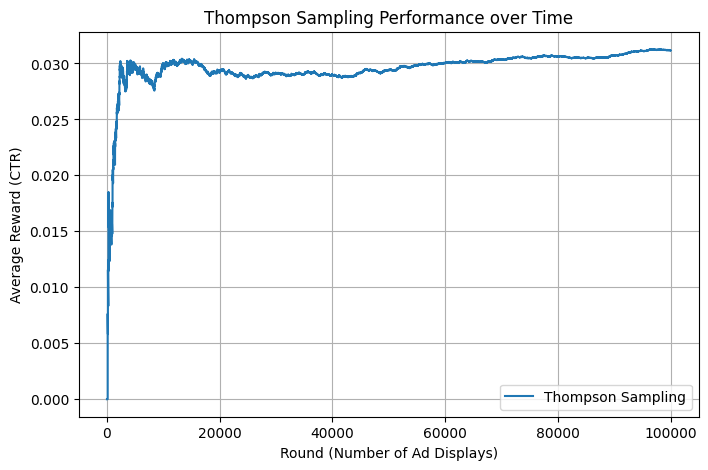

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(avg_rewards, label='Thompson Sampling', color='tab:blue')
plt.xlabel('Round (Number of Ad Displays)')
plt.ylabel('Average Reward (CTR)')
plt.title('Thompson Sampling Performance over Time')
plt.legend()
plt.grid(True)
plt.show()

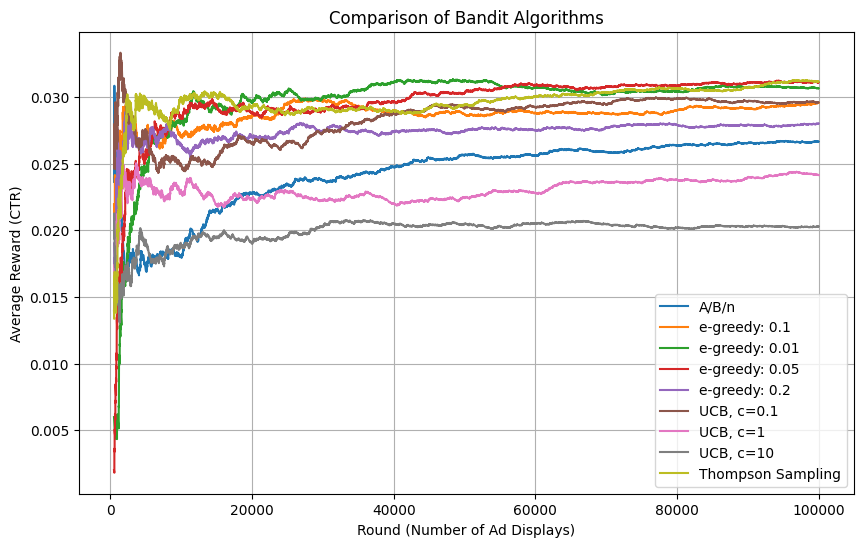

In [ ]:
import matplotlib.pyplot as plt

# Slice starting from further time step
df_plot = df_reward_comparison.iloc[500:]

plt.figure(figsize=(10, 6))
for col in df_reward_comparison.columns:
    plt.plot(df_plot[col], label=col)

plt.xlabel('Round (Number of Ad Displays)')
plt.ylabel('Average Reward (CTR)')
plt.title('Comparison of Bandit Algorithms')
plt.legend()
plt.grid(True)
plt.show()

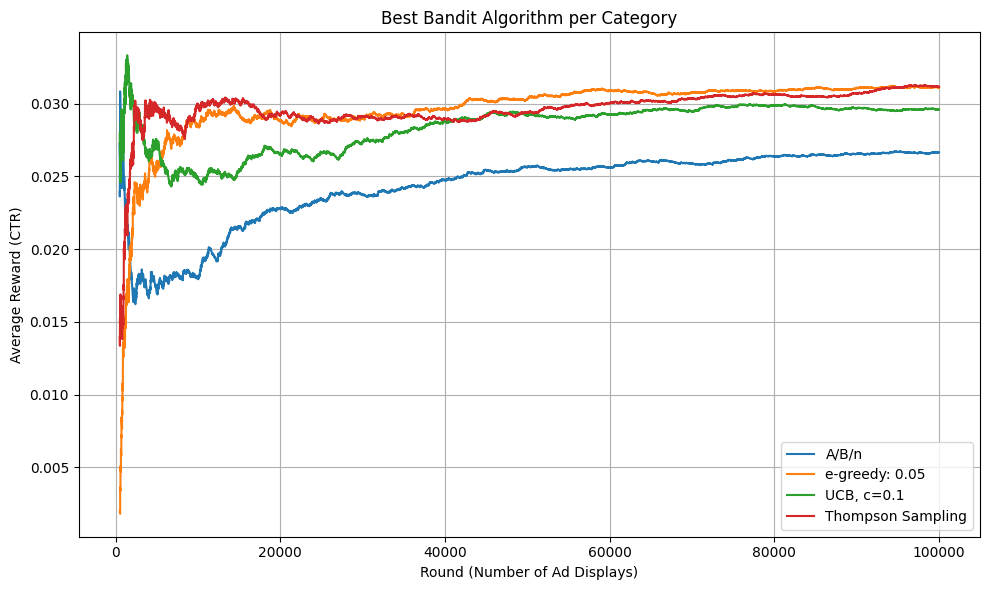

Selected for plotting: ['A/B/n', 'e-greedy: 0.05', 'UCB, c=0.1', 'Thompson Sampling']


In [ ]:
import matplotlib.pyplot as plt

# Helper function: get best-performing column per keyword pattern
def get_best_column(df, keyword):
    cols = [c for c in df.columns if keyword in c]
    if not cols:
        return None
    return max(cols, key=lambda c: df[c].iloc[-1])  # highest final reward

# Find best per family
best_abn_col = 'A/B/n' if 'A/B/n' in df_reward_comparison.columns else None
best_eps_col = get_best_column(df_reward_comparison, 'e-greedy')
best_ucb_col = get_best_column(df_reward_comparison, 'UCB')
best_thompson_col = get_best_column(df_reward_comparison, 'Thompson')

# Combine and filter out missing
selected_cols = [c for c in [best_abn_col, best_eps_col, best_ucb_col, best_thompson_col] if c]

# Slice starting from further time step
df_plot = df_reward_comparison.iloc[500:]

# Plot results
plt.figure(figsize=(10, 6))
for col in selected_cols:
    plt.plot(df_plot[col], label=col)

plt.xlabel('Round (Number of Ad Displays)')
plt.ylabel('Average Reward (CTR)')
plt.title('Best Bandit Algorithm per Category')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Selected for plotting:", selected_cols)
